In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 659.4/659.4 kB 8.1 MB/s eta 0:00:00


In [2]:
import numpy as np
from PIL import Image
import cv2
import tensorflow as tf
from keras.models import load_model
import base64
from ultralytics import YOLO

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def return_mask(image, masks, labels, boxes):
    mask_image = np.zeros_like(image)

    height, width, _ = image.shape

    for mask, label, box in zip(masks, labels, boxes):
        xmin, ymin, xmax, ymax = list(map(int, box))

        # Calculate the thickness and text size based on image dimensions
        thickness = max(int(min(height, width) / 200), 1)
        text_size = max(int(min(height, width) / 800), 1)
        R = np.random.randint(0, 52) * 5
        G = np.random.randint(0, 52) * 5
        B = 0
        color = (0, 0, 255) #BGR

        mask_coords = np.array(mask, dtype=np.int32)
        cv2.fillPoly(mask_image, [mask_coords], color)
        # cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, thickness)
        cv2.putText(image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, text_size, color, thickness)

    alpha = 0.4  # Transparency level for the mask
    image_with_masks = cv2.addWeighted(image, 1 - alpha, mask_image, alpha, 0)
    # image_with_masks = cv2.cvtColor(image_with_masks, cv2.COLOR_BGR2RGB)
    plt.imshow(image_with_masks)
    plt.title(f'Cuts detected {len(boxes)}')
    plt.show()

In [7]:
yolo = YOLO(r'/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/prawn.pt')
red = YOLO(r'/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/red.pt')
# nprawn =YOLO(r'/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/nano_prawn.pt')
# mprawn = YOLO(r'/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/medium_prawn.pt')
# lprawn = YOLO(r'/content/drive/MyDrive/Kartik /Prawns(STACKED_MODEL)/large_prawn.pt')

In [8]:
def extract_single_image_segment(img, mask_segment, shape):
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]
    black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
    segment_image[black_mask] = [255, 255, 255]
    return segment_image

In [9]:
def process_image(image):
    resized_image = resize_image(image, size=(224, 224))
    resized_image = cv2.resize(resized_image,(224,224))
    processed_image = resized_image/255.0
    processed_image = np.expand_dims(processed_image, axis=0)
    return tf.convert_to_tensor(processed_image, dtype=tf.float32)
def resize_image(image, size):
    h, w = image.shape[0],image.shape[1]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)
    resized_image = cv2.resize(image, (new_w, new_h))
    padded_image = pad_image(resized_image, size)
    return padded_image
def pad_image(image, size):
    h, w = image.shape[0], image.shape[1]
    pad_h = (size[1] - h) // 2
    pad_w = (size[0] - w) // 2
    padded_image = cv2.copyMakeBorder(
        image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    return padded_image
def load_image(image):
    image = np.array(image)
    processed_image = process_image(image)
    return processed_image
def threshold(predictions):
    return np.where(predictions > 0.68, 1, 0)

def freshness_prediction(image, raw=False):
  if raw:
    return prawn.predict(load_image(image),verbose=0)[0][0]
  classes = {1:"Good", 0:"Bad"}
  pred = red.predict(image, conf=0.6, verbose=False)
  if len(pred[0].boxes.xyxy) == 0 or pred[0].masks == None:
    return threshold(prawn.predict(load_image(image),verbose=0))[0][0]
  else:
    return 0


In [10]:
def final_prediction2(image,raw=False):
  image = Image.open(image)
  image = np.asarray(image)
  shape = image.shape
  try:
     pred = yolo.predict(image, conf=0.75, verbose=False)
  except:
     return None
  if len(pred[0].boxes.xyxy) == 0 or pred[0].masks == None:
     return None
  boxes = pred[0].boxes.xyxy
  masks=pred[0].masks.xy
  filtered_boxes = sorted(boxes, key=lambda bbox: bbox[0])
  sorted_masks = [masks[i] for i in sorted(range(len(masks)), key=lambda x: boxes[x][0])]
  freshness = []
  for mask in sorted_masks:
    extracted_image = extract_single_image_segment(image, mask, shape)
    freshness.append(freshness_prediction(extracted_image,raw))
  return freshness

In [ ]:
final_prediction2('/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/Mackerel/Bad/20230520105846433_mackerel_bad.jpeg',raw=False)

[1]

In [ ]:
from glob import glob
from tqdm import tqdm
bad_images = glob('/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/White prawns/Bad/*.jpeg')[::2]
good_images = glob('/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/White prawns/Good/*.jpeg')[::2]

len(bad_images),len(good_images)

(1550, 1341)

In [ ]:
# true= []
# pred = [0] * len(bad_images)
# pred+= [1] * len (good_images)
# for img in tqdm(bad_images[::2]):
#   image = Image.open(img)
#   image = np.asarray(image)
#   res = red.predict(image, conf=0.6, verbose=False)
#   if len(res[0].boxes.xyxy) == 0 or res[0].masks == None:
#     pred.append(1)
#   else:
#     pred.append(0)

# for img in tqdm(good_images[::2]):
#   image = Image.open(img)
#   image = np.asarray(image)
#   image = Image.open(img)
#   image = np.asarray(image)
#   res = red.predict(image, conf=0.6, verbose=False)
#   if len(res[0].boxes.xyxy) == 0 or res[0].masks == None:
#     pred.append(1)
#   else:
#     pred.append(0)

In [ ]:
results= {}
actual = {}
raw_labels=[]
actual_labels = []
predicted_labels = []
for img in tqdm(bad_images):
  try:
      lst = final_prediction2(img)
      raw_labels+=final_prediction2(img, raw=True)
  except:
      continue
  if lst == None:
    continue
  actual_labels += [0] * len(lst)
  predicted_labels+=lst
  good = lst.count(1)
  bad = lst.count(0)
  actual['Bad'] = results.get(0, 0) + bad + good
  results['Good'] = results.get(1, 0) + good
  results['Bad'] = results.get(0, 0) + bad


for img in tqdm(good_images):
  try:
      lst = final_prediction2(img)
      raw_labels+=final_prediction2(img, raw=True)
  except:
      continue
  if lst == None:
    continue
  actual_labels += [1] * len(lst)
  predicted_labels+=lst
  good = lst.count(1)
  bad = lst.count(0)
  actual['Good'] = results.get(1, 0) + bad + good
  results['Good'] = results.get(1, 0) + good
  results['Bad'] = results.get(0, 0) + bad

100%|██████████| 1341/1341 [53:50<00:00,  2.41s/it]


In [ ]:
# from sklearn.metrics import roc_curve, roc_auc_score, f1_score
# import matplotlib.pyplot as plt
# model_predictions = raw_labels
# true_labels = actual_labels

# # Compute ROC curve
# fpr, tpr, thresholds = roc_curve(true_labels, model_predictions)

# # Plot ROC curve
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, label='ROC curve')
# plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend()

# # Calculate AUC (Area Under the ROC Curve)
# roc_auc = roc_auc_score(true_labels, model_predictions)
# print(f"AUC (Area Under the ROC Curve): {roc_auc:.2f}")

# # Find the optimal threshold based on F1-score
# f1_scores = 2 * (tpr * (1 - fpr)) / (tpr + (1 - fpr))
# optimal_threshold = thresholds[np.argmax(f1_scores)]
# print(f"Optimal Threshold for F1-Score: {optimal_threshold:.2f}")

# diff = tpr - fpr
# idx = np.argmax(diff)
# optimal_threshold2 = thresholds[idx]
# print(f"Optimal Threshold 2: {optimal_threshold2:.2f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


def generate_classification_report(true_labels, predicted_labels, labels):
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='macro')
    recall = recall_score(true_labels, predicted_labels, average='macro')
    f1 = f1_score(true_labels, predicted_labels, average='macro')

    classification_rep = classification_report(true_labels, predicted_labels)
    confusion_mat = confusion_matrix(true_labels, predicted_labels)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("\nClassification Report:")
    print(classification_rep)

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.xticks(ticks=range(len(labels)), labels=labels)
    plt.yticks(ticks=range(len(labels)), labels=labels)
    name = 'Fresh'
    plt.savefig(name+'Mackerel_Confusion_matrix_today.png')
    plt.show()
    return int(accuracy_score(true_labels, predicted_labels)*100)

Accuracy: 0.5891428571428572
Precision: 0.5889902115257448
Recall: 0.5891066042131594
F1-score: 0.5889280930445293

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.59      0.60      1815
           1       0.57      0.59      0.58      1685

    accuracy                           0.59      3500
   macro avg       0.59      0.59      0.59      3500
weighted avg       0.59      0.59      0.59      3500



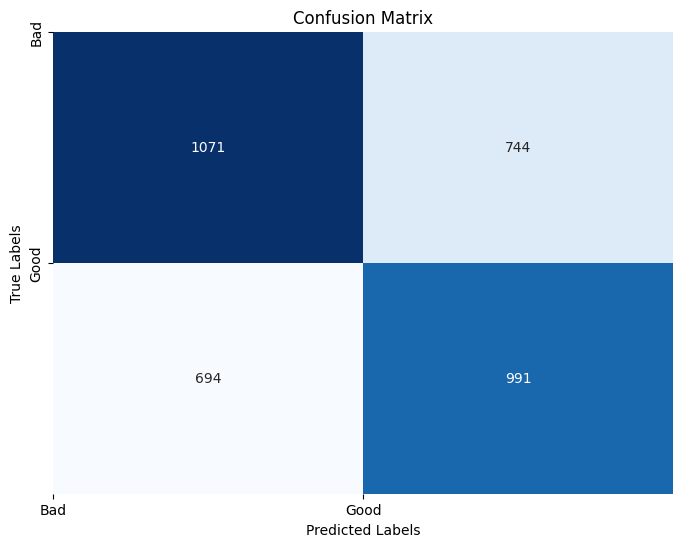

58

In [ ]:
generate_classification_report(actual_labels, predicted_labels, ['Bad', 'Good'])